# The coordinates perturbation for investgating the gene-gene co-occurrent robustness

- ***Motivation***:  
  Spatial technologies inherently own the incorrectness of gene spatial coordinations and cell segmentation. The definition of our gene-gene co-occurrence should be largely based on the accurate positional information.
  Therefore, we assay the gene pairs robustness based on different level of perturbations in this notebook

- ***test files***
  - Brain: from Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs as [***brain_transcripts.csv.gz***](https://figshare.com/account/projects/238169/articles/30627677)
  - Lung: from GSM7990543_output-XETG00048__0003817__VUILD102LA__20230308__003731 as [**lung_transcripts.csv.gz***](https://figshare.com/account/projects/238169/articles/30627677)
  

In [1]:
import sys
sys.path.append("/scratch/project_465001820/Spatialformer/data_preprocessing")
from process import KNN_Radius_Graph
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import List, Dict, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Optional
import pandas as pd
from dask.distributed import Client
import itertools
from tqdm.auto import tqdm
from dask.distributed import as_completed

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("ok")

ok


In [19]:

def get_gco(gene_binary_matrix: np.ndarray, all_genes: List[str]) -> List:
    """
    Get the non-redundance gene pairs from the co-occurrence matrix

    Args:
    gene_binary_matrix: np.ndarray, the binary gene-gene co-occurrence matrix
    all_genes: List. A list with all the gene names in the dataset
    ==========
    Return:
    gene_pair: a single list that contains the paired gene pairs 
    
    """
    all_genes = list(sorted(all_genes))
    
    # Create upper triangle mask (excluding diagonal)
    upper_triangle = np.triu(gene_binary_matrix, k=1)
    
    # Find non-zero positions in upper triangle
    nonzero_rows, nonzero_cols = np.where(upper_triangle != 0)
    nonzero_values = gene_binary_matrix[nonzero_rows, nonzero_cols]
    
    gene_pair = []
    
    for row, col in zip(nonzero_rows, nonzero_cols):
        gene_pair.append([all_genes[row], all_genes[col]])
    return gene_pair
def gaussian_noise(df: pd.DataFrame = None, std: int = 0, iteration: int = 0) -> pd.DataFrame:
    """
    Add gaussian noise to the transcript spatial coordinates

    Args:
    df: dataframe of the transcripts.csv file
    std: the standard deviation of the perturbation, which indicates the strength of the noise.
    ==============================
    Return:
    the perturbed dataframe

    """
    perturb_df = df.copy()
    #noise level
    noise_x = np.random.normal(0, std, perturb_df.shape[0])
    noise_y = np.random.normal(0, std, perturb_df.shape[0])
    noise_z = np.random.normal(0, std, perturb_df.shape[0])

    # accumulate the noise
    if iteration == 0:
        perturb_df["x_0"] = perturb_df["x"] + noise_x
        perturb_df["y_0"] = perturb_df["y"] + noise_y
        perturb_df["z_0"] = perturb_df["z"] + noise_z
    else:
        perturb_df[f"x_{iteration}"] = perturb_df[f"x_{iteration-1}"] + noise_x
        perturb_df[f"y_{iteration}"] = perturb_df[f"y_{iteration-1}"] + noise_y
        perturb_df[f"z_{iteration}"] = perturb_df[f"z_{iteration-1}"] + noise_z


    #assign the noise back to the original coordinates
    perturb_df["x"] = perturb_df[f"x_{iteration}"]
    perturb_df["y"] = perturb_df[f"y_{iteration}"]
    perturb_df["z"] = perturb_df[f"z_{iteration}"]
    return perturb_df

def metric(gene_pair1: List, gene_pair2: List)-> float:
    """
    evaluation of the robustness

    Args:
    gene_pair1: List, the reference gene pairs that were originally detected by the actual coordinate system
    gene_pair2: List, the gene pairs that were found when the perturbed coordinates were introduced
    ============================
    Return:
    
    """
    # Convert to numpy array
    gene_pair1_arr = np.array(gene_pair1)
    gene_pair2_arr = np.array(gene_pair2)
    # Find common pairs using broadcasting
    # This creates a 3D boolean array and checks for any matches
    mask = np.any(np.all(gene_pair2_arr[:, np.newaxis] == gene_pair1_arr, axis=2), axis=1)
    rec_pairs = np.where(mask)[0]
    keep_pct = len(rec_pairs)/len(gene_pair1)
    # print(gene_pair1_arr, gene_pair2_arr, mask, rec_pairs, keep_pct)
    return keep_pct
    
def plot_robustness_seaborn(pct_dict: Dict, title="Robustness Analysis", filename="demo"):
    """
    Plot robustness using Seaborn for better styling
    Args：
    pct_dict: Dict. the dictionary of the results. keys are the iteration and values are the pct of each cell as a list
    ========================
    Return:
    A plot for visualization
    """
    # Convert dictionary to DataFrame
    df = pd.DataFrame([
        {"Iteration": k+1, "Re_occurrence_rate": val}
        for k, values in pct_dict.items()
        for val in values
    ])

    # Compute mean and std per iteration
    stats = df.groupby("Iteration")["Re_occurrence_rate"].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(10, 6))

    # Plot shaded band (mean ± std)
    plt.fill_between(
        stats["Iteration"],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.25,
        label="Std. deviation band"
    )

    # Plot mean line
    sns.lineplot(
        data=stats,
        x="Iteration",
        y="mean",
        marker=None,
        linewidth=2.5,
        markersize=8,
        label="Mean re-occurrence rate"
    )

    # Labeling & aesthetics
    plt.xlabel("Iterations", fontsize=20, fontweight="bold")
    plt.ylabel("Re-occurrence (%)", fontsize=20, fontweight="bold")
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(magic_path("figures", filename), dpi=300)
    plt.show() 


def boundary_selection(df: pd.DataFrame, quantile: float = 0.95, frac: float = 0.9):
    """
    Randomly select the transcripts in the boundary

    Args:
    df: pd.DataFrame. The dataframe waits for filtering
    quantile: float. The quantile of the distance to the nucleus. default 0.8.
    frac: float. The fraction of the transcripts that used to be selected in the boundary region
    ====================
    Return:
    the filtered dataframe
    
    
    """
        
    # keep all that are close to the nucleus
    df_nucleus = df[df["overlaps_nucleus"] == 1]

    df_cyto = df[df["overlaps_nucleus"] == 0]

    # Compute xth percentile value
    val_pct = df_cyto["nucleus_distance"].quantile(quantile)

    
    # Bottom x%: randomly select 20%
    df_cytp_kp = df_cyto[(df_cyto["nucleus_distance"] < val_pct)]
    df_bdr = df_cyto[(df_cyto["nucleus_distance"] >= val_pct)]
    # print("df_nucleus:", df_nucleus.shape)
    # print("df_cytp_kp:", df_cytp_kp.shape)
    df_sample = df_bdr.sample(frac=frac)
    # print("df_sample:", df_sample.shape)
    
    # Combine
    df_selected = pd.concat([df_nucleus, df_cytp_kp, df_sample]).reset_index(drop=True)
    # all_genes = df_selected["gene"]
    return df_selected
def run_for_sc(df: pd.DataFrame, cell_id: str, all_genes: List, std: int, iteration: int, boundary_noise: bool, quantile: float, frac: float) -> float:
    """
    The main function for a single cell to get the gene robustness

    Args:
    df: pd.DataFrame. The filtered transcript dataframe with all the transcripts' info
    cell_id: str. The cell barcode id.
    all_genes: List. All the genes detected in the datasets.
    std: int. The standard deviation of the noise that is introduced to the transcripts.
    iteration: int. The nth iteration of the perturbation. The perturbation should be accumulated.
    boundary_noise: bool. Whether considering the uncertainty of the cell boundary
    ==========================
    Return:
    The percentage of the genes remains.
    """

    # getting the reference gene pairs for comparing
    data_graph = KNN_Radius_Graph(radius=5, dataset=df, is_3D=True, cell_ID=cell_id, ref_gene=all_genes)
    gene_binary_matrix, gene_freq_matrix, trans_matrix = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    ref_gene_pairs = get_gco(gene_binary_matrix, all_genes)
    
    if boundary_noise:
        
        #introducing the noise
        df_noise = gaussian_noise(df = df, std = std, iteration = iteration)
        # get the subset of the dataframe according to the cell boundary
        # print("before:", df_noise.shape)
        df_noise_bd = boundary_selection(df_noise, quantile, frac)
        # print("df_noise", df_noise.columns)
        # print("after:",df_noise_bd.shape)
        data_graph = KNN_Radius_Graph(radius=5, dataset=df_noise_bd, is_3D=True, cell_ID=cell_id, ref_gene=all_genes)
        # print("data_graph:", data_graph)

    else:
        #introducing the noise
        df_noise = gaussian_noise(df = df, std = std, iteration = iteration)
   

        data_graph = KNN_Radius_Graph(radius=5, dataset=df_noise, is_3D=True, cell_ID=cell_id, ref_gene=all_genes)
    gene_binary_matrix_n, gene_freq_matrix_n, trans_matrix_n = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    # print("1")
    ptb_gene_pairs = get_gco(gene_binary_matrix_n, all_genes)
    # print("2")
    # print("ref pairs:", ref_gene_pairs)
    # print("ptb pairs:", ptb_gene_pairs)
    pct = metric(ref_gene_pairs, ptb_gene_pairs)
    # print("3")
    # print("pct:", pct)
    # print("df_noise:", df_noise)
    
    return pct, df_noise

In [15]:
# ----------------------------
# Optimized Dask-enabled Perturb class
# ----------------------------


class Perturb:
    def __init__(self, df: pd.DataFrame, std: int = 20, limit_cells: Optional[int] = None):
        self.std = std
        self.df = df.copy()
        self.df_flt = self.qc()
        all_cell_ids = list(self.df_flt["cell_id"].unique())
        if limit_cells:
            all_cell_ids = all_cell_ids[:limit_cells]
        self.cell_ids = all_cell_ids
        self.all_genes = self.df_flt["gene"].unique().tolist()

    def qc(self) -> pd.DataFrame:
        """Run QC and return filtered dataframe."""
        rename_map = {}
        if "x_location" in self.df.columns:
            rename_map["x_location"] = "x"
        if "y_location" in self.df.columns:
            rename_map["y_location"] = "y"
        if "z_location" in self.df.columns:
            rename_map["z_location"] = "z"
        if "feature_name" in self.df.columns:
            rename_map["feature_name"] = "gene"
        if rename_map:
            self.df = self.df.rename(columns=rename_map)
        # print("qc df:", self.df)
        # More efficient filtering
        df_flt1 = self.df[
            ~(self.df["gene"].str.startswith("Neg") |
              self.df["gene"].str.startswith("BLANK") |
              self.df["gene"].str.startswith("Unassigned"))
        ].copy()

        # Optimized cell filtering
        vc = df_flt1["cell_id"].value_counts()
        if "UNASSIGNED" in vc.index:
            vc = vc.drop("UNASSIGNED")
        good_cells = vc[vc >= 30].index
        df_flt2 = df_flt1[df_flt1["cell_id"].isin(good_cells)].reset_index(drop=True)
        return df_flt2

    def run_for_allcell_dask_optimized(
        self,
        client: Optional[Client] = None,
        batch_size: int = 200,
        boundary_noise: bool = False,
        n_iter:int = 0,
        quantile: float = 0.0,
        frac: float = 0.2
    ) -> Tuple[List, pd.DataFrame]:
        
        created_client = False
        if client is None:
            # Optimized client configuration
            client = Client(
                n_workers=min(60, os.cpu_count() * 4),  # Don't overload system
                threads_per_worker=1,  # Better for CPU-bound tasks
                memory_limit='auto',
                processes=True  # Use processes instead of threads
            )
            created_client = True

        try:
            # Pre-group data once
            cell_id_to_group = self.df_flt.groupby("cell_id")
            ids = [cid for cid in self.cell_ids if cid in cell_id_to_group.groups]
            
            # Use futures list for better resource management
            futures = []
            batch_info = []
            
            # Process in larger batches with progress tracking
            for i in range(0, len(ids), batch_size):
                batch_ids = ids[i:i + batch_size]

                small_dfs = [cell_id_to_group.get_group(cid).reset_index(drop=True) 
                           for cid in batch_ids]

                
                # Submit entire batch at once
                batch_futures = client.map(
                    run_for_sc, 
                    small_dfs, 
                    batch_ids,
                    [self.all_genes] * len(batch_ids),
                    [self.std] * len(batch_ids),
                    [n_iter] * len(batch_ids),
                    [boundary_noise] * len(batch_ids),
                    [quantile] * len(batch_ids),
                    [frac] * len(batch_ids)
                )
                
                # Store futures with their original indices
                for j, (fut, cid) in enumerate(zip(batch_futures, batch_ids)):
                    futures.append(fut)
                    batch_info.append((i + j, cid))

            # Collect results more efficiently
            results = []
            df_results = []
            failed_cells = []
            
            # Use as_completed for better throughput
            
            completed = as_completed(futures)
            
            # Track progress with ordered results
            temp_results = [None] * len(futures)
            temp_dfs = [None] * len(futures)
            
            for future in completed:
                try:
                    result, df_result = future.result(timeout=600)  # Increased timeout
                    # print("df_result111:", df_result)
                    # Find original position
                    idx = next(i for i, (pos, cid) in enumerate(batch_info) 
                             if futures[i] == future)
                    original_idx, cell_id = batch_info[idx]
                    temp_results[original_idx] = result
                    temp_dfs[original_idx] = df_result
                    
                except Exception as e:
                    # print("faild.....")
                    # Find which cell failed
                    idx = next(i for i, (pos, cid) in enumerate(batch_info) 
                             if futures[i] == future)
                    _, cell_id = batch_info[idx]
                    # print(f"Failed to process cell {cell_id}: {type(e).__name__}: {str(e)}")
                    failed_cells.append(cell_id)
            # print("temp_dfs:", temp_dfs)
            # Filter out None results (failed cells)
            results = [r for r in temp_results if r is not None]
            df_results = [df for df in temp_dfs if df is not None]

        finally:
            if created_client:
                client.close()

        # print(f"\nSuccessfully processed: {len(results)} cells")
        # print(f"Failed: {len(failed_cells)} cells")
        if failed_cells:
            print(f"Failed cell IDs: {failed_cells[:10]}{'...' if len(failed_cells) > 10 else ''}")

        # Concatenate results more efficiently
        if df_results:
            new_df = pd.concat(df_results, axis=0, ignore_index=True)
        else:
            new_df = pd.DataFrame()
        # print(new_df.head())
        return results, new_df



# Optimized main execution
def run_optimized_pipeline(raw_df, iter_num=100, limit_cells=500, std=1, boundary_noise: bool=False, quantile: float=0.8, frac: float=0.8, batch_size: int=100):
    """
    Optimized pipeline execution with better resource management
    """
    # Create client once and reuse
    client = Client(
        n_workers=min(50, os.cpu_count() * 3),
        threads_per_worker=1,
        memory_limit='50GB',
        processes=True
    )
    
    results = {}

    current_df = raw_df
    
    try:
        
        for i in tqdm(range(iter_num), desc=f"Running iteration for {limit_cells} cells"):
            
            p = Perturb(df=current_df, limit_cells=limit_cells, std=std)
            # Use optimized method
            result, df_result = p.run_for_allcell_dask_optimized(
                client=client, 
                batch_size=batch_size,  # batch size
                boundary_noise=boundary_noise,
                n_iter=i,
                quantile=quantile,
                frac=frac
            )
            # print("df_result:", df_result)
            results[i] = result
            current_df = df_result
            # print("current_df2:", df_result)
            
            
            print(f"Iteration {i+1}: Processed {len(result)} cells successfully")
            
    finally:
        client.close()
        
    return results, current_df



path settings

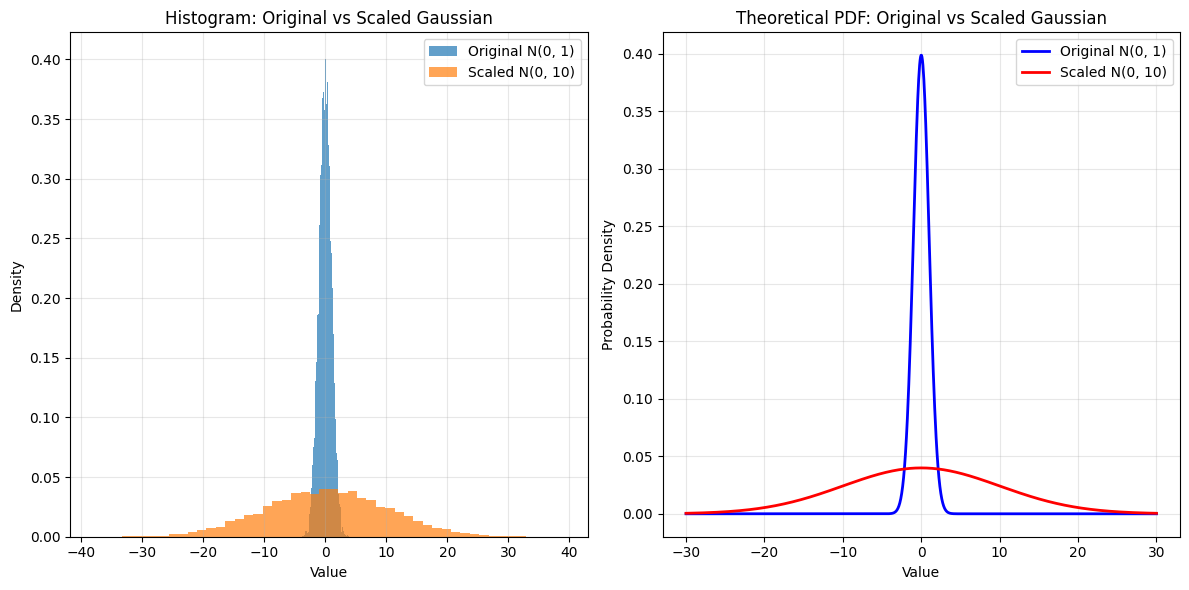

Original noise statistics:
  Mean: 0.0109
  Std: 1.0064

Scaled noise statistics:
  Mean: 0.1093
  Std: 10.0636
  Expected Std: 10


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the parameters
std = 1  # Original standard deviation
n_samples = 10000  # Number of samples

# Generate the original Gaussian noise
noise_x = np.random.normal(0, std, n_samples)

# Create the scaled version (multiplied by 10)
scaled_noise = 10 * noise_x

# Plot both distributions
plt.figure(figsize=(12, 6))

# Plot 1: Histograms
plt.subplot(1, 2, 1)
plt.hist(noise_x, bins=50, alpha=0.7, label=f'Original N(0, {std})', density=True)
plt.hist(scaled_noise, bins=50, alpha=0.7, label=f'Scaled N(0, {10*std})', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram: Original vs Scaled Gaussian')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Probability Density Function (theoretical curves)
plt.subplot(1, 2, 2)
x = np.linspace(-30, 30, 1000)
original_pdf = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x/std)**2)
scaled_pdf = (1/(10*std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x/(10*std))**2)

plt.plot(x, original_pdf, 'b-', linewidth=2, label=f'Original N(0, {std})')
plt.plot(x, scaled_pdf, 'r-', linewidth=2, label=f'Scaled N(0, {10*std})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Theoretical PDF: Original vs Scaled Gaussian')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics to verify
print(f"Original noise statistics:")
print(f"  Mean: {np.mean(noise_x):.4f}")
print(f"  Std: {np.std(noise_x):.4f}")

print(f"\nScaled noise statistics:")
print(f"  Mean: {np.mean(scaled_noise):.4f}")
print(f"  Std: {np.std(scaled_noise):.4f}")
print(f"  Expected Std: {10 * std}")

In [6]:
current_path = "/scratch/project_465001820/Spatialformer/downstream/Coordinate_perturbation"
magic_path = lambda *x: os.path.join(os.path.abspath(current_path), *x)

# Visualizing the std

NameError: name 'current_df' is not defined

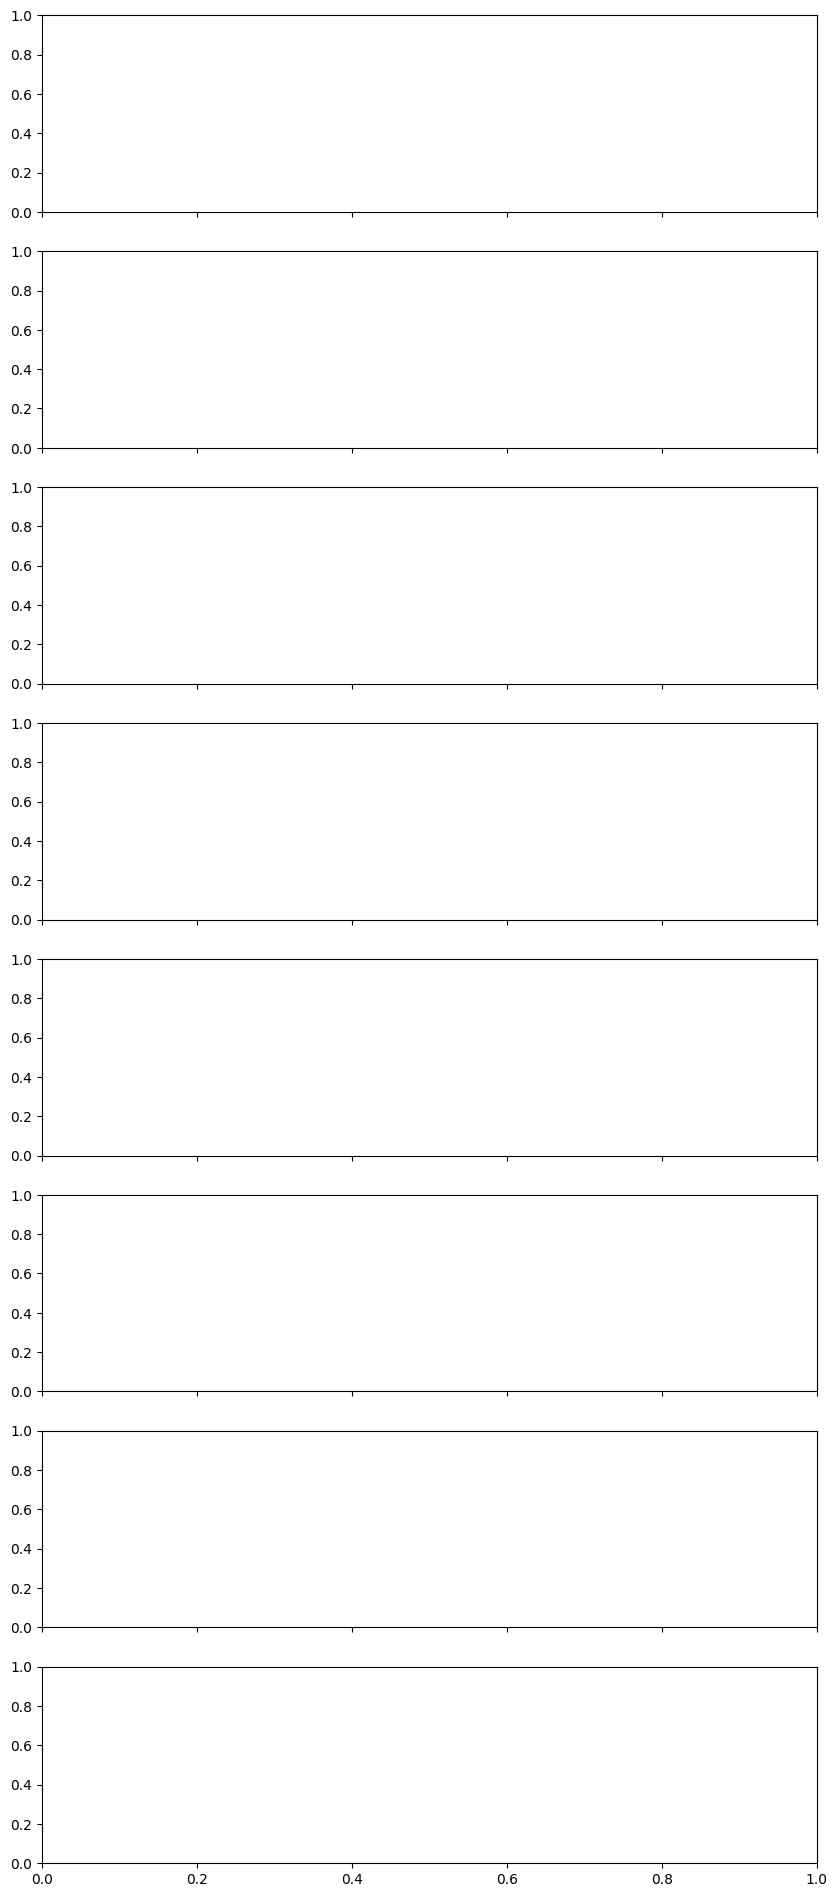

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Number of subplots = 8 (for i from 2 to 9)
n_plots = 8
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3*n_plots), sharex=True)

for idx, i in enumerate(range(2, 100, 10)):
    ax = axes[idx]  # select subplot
    
    # Select only x_0 to x_{i-1} columns
    cols = [f"x_{j}" for j in range(i)]
    
    # Transpose so columns become series for plotting
    plot_df = current_df[cols].T.iloc[:, :10]
    
    # Plot horizontal KDE for each column
    for col in plot_df.columns:
        sns.kdeplot(plot_df[col], ax=ax, vertical=False, label=col)
    
    ax.set_title(f"Density plot for {i} columns")
    ax.legend(loc="upper right")

plt.xlabel("Value")
plt.tight_layout()
plt.show()


# Introducing the Gaussian noise for the coordinates (x and y)
- To see differences before and after perturbation in lung tissue

In [9]:
# Usage
import os
from dask.distributed import Client
import pandas as pd
from tqdm import tqdm
from typing import Optional, List, Tuple
import pickle
# Silence stdout/stderr of Dask workers completely
# ---------------------------
os.environ["DASK_DISTRIBUTED__LOGGING__DISTRIBUTED"] = "error"
os.environ["DASK_DISTRIBUTED__LOGGING__BOKEH"] = "error"
os.environ["DASK_DISTRIBUTED__LOGGING__TQDM"] = "error"
# loading the .csv path
lung_annot_3D_tx = pd.read_csv(magic_path("data", "lung_transcripts.csv.gz"), compression='gzip') 
# Run the optimized pipeline
lung_results_bd_noise, current_df = run_optimized_pipeline(
    raw_df=lung_annot_3D_tx,
    iter_num=100,
    limit_cells=500,
    std=0.2,                             
    boundary_noise=True,
    quantile=0.90,
    frac=0.80,
    batch_size=50
)


pickle.dump(lung_results_bd_noise, open(magic_path("data", "lung_results_bd_noise.pkl"),"wb"))

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43097 instead
  warnings.warn(
Running iteration for 500 cells:   1%|          | 1/100 [00:48<1:20:06, 48.55s/it]

Failed cell IDs: ['aaaaebjb-1', 'aaaaahld-1', 'aaaaeona-1']
Iteration 1: Processed 497 cells successfully


Running iteration for 500 cells:   2%|▏         | 2/100 [01:02<45:34, 27.91s/it]  

Failed cell IDs: ['aaaaechh-1']
Iteration 2: Processed 496 cells successfully


Running iteration for 500 cells:   3%|▎         | 3/100 [01:15<34:19, 21.23s/it]

...

Running iteration for 500 cells:  99%|█████████▉| 99/100 [33:03<00:25, 25.29s/it]

Iteration 99: Processed 473 cells successfully


Running iteration for 500 cells: 100%|██████████| 100/100 [33:28<00:00, 20.08s/it]

Iteration 100: Processed 473 cells successfully



/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipyk

run without the boundary noise

In [11]:
# Run the optimized pipeline
lung_results_nbd_noise, current_df = run_optimized_pipeline(
    raw_df=lung_annot_3D_tx,
    iter_num=100,
    limit_cells=500,
    std=0.2,                             
    boundary_noise=False,
    quantile=0.90,
    frac=0.80,
    batch_size=50
)

pickle.dump(lung_results_nbd_noise, open(magic_path("data", "lung_results_nbd_noise.pkl"),"wb"))

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33497 instead
  warnings.warn(
Running iteration for 500 cells:   1%|          | 1/100 [00:53<1:28:06, 53.40s/it]

Failed cell IDs: ['aaaaebjb-1', 'aaaaahld-1', 'aaaaeona-1']
Iteration 1: Processed 497 cells successfully


Running iteration for 500 cells:   2%|▏         | 2/100 [01:07<49:13, 30.14s/it]  

Failed cell IDs: ['aaaaeamc-1']
Iteration 2: Processed 496 cells successfully


Running iteration for 500 cells:   3%|▎         | 3/100 [01:21<36:49, 22.77s/it]

...

Running iteration for 500 cells:  99%|█████████▉| 99/100 [33:39<00:25, 25.70s/it]

Iteration 99: Processed 473 cells successfully


Running iteration for 500 cells: 100%|██████████| 100/100 [34:06<00:00, 20.47s/it]

Iteration 100: Processed 473 cells successfully



/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/1654152502.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipyk

# Run for brain data

With boundary noise

In [22]:
# loading the .csv path
brain_annot_3D_tx = pd.read_csv(magic_path("data", "brain_transcripts.csv.gz"), compression='gzip') 
# Run the optimized pipeline
brain_results_bd_noise, current_df = run_optimized_pipeline(
    raw_df=brain_annot_3D_tx,
    iter_num=100,
    limit_cells=500,
    std=0.2,                             
    boundary_noise=True,
    quantile=0.90,
    frac=0.80,
    batch_size=10
)
# import pickle
pickle.dump(brain_results_bd_noise, open(magic_path("data", "brain_results_bd_noise.pkl"),"wb"))

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46235 instead
  warnings.warn(
Running iteration for 500 cells:   1%|          | 1/100 [02:06<3:29:23, 126.91s/it]

Failed cell IDs: ['fkjodcbc-1', 'fkjbmboh-1', 'fkjimhac-1', 'fkpbjoca-1', 'noajoepf-1', 'flecmoal-1', 'ajideppk-1', 'hfgfeabo-1', 'hfiokafb-1', 'cchejojc-1']...
Iteration 1: Processed 455 cells successfully
Failed cell IDs: ['flbncopo-1', 'cclieboi-1', 'ccafidib-1', 'cbkegiom-1', 'cbkfamap-1', 'ccealmfn-1']


Running iteration for 500 cells:   2%|▏         | 2/100 [02:18<1:36:48, 59.27s/it] 

Iteration 2: Processed 449 cells successfully
Failed cell IDs: ['fkiohbfi-1', 'hfhklldm-1']
Iteration 3: Processed 447 cells successfully


Running iteration for 500 cells:   3%|▎         | 3/100 [02:31<1:01:42, 38.17s/it]

...

Running iteration for 500 cells:  99%|█████████▉| 99/100 [35:15<00:27, 27.23s/it]

Iteration 99: Processed 381 cells successfully


Running iteration for 500 cells: 100%|██████████| 100/100 [35:41<00:00, 21.41s/it]

Iteration 100: Processed 381 cells successfully



/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipyk

without boundary noise

In [23]:
# loading the .csv path
brain_annot_3D_tx = pd.read_csv(magic_path("data", "brain_transcripts.csv.gz"), compression='gzip') 
# Run the optimized pipeline
brain_results_nbd_noise, current_df = run_optimized_pipeline(
    raw_df=brain_annot_3D_tx,
    iter_num=100,
    limit_cells=500,
    std=0.2,                             
    boundary_noise=False,
    quantile=0.90,
    frac=0.80,
    batch_size=10
)
import pickle
pickle.dump(brain_results_nbd_noise, open(magic_path("data", "brain_results_nbd_noise.pkl"),"wb"))

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45607 instead
  warnings.warn(
Running iteration for 500 cells:   0%|          | 0/100 [00:00<?, ?it/s]

Failed cell IDs: ['fkjodcbc-1', 'fkpbjoca-1', 'fkjbmboh-1', 'flbncopo-1', 'fkjimhac-1', 'noajoepf-1', 'flecmoal-1', 'ajideppk-1', 'hfgfeabo-1', 'ccnaoalp-1']...


Running iteration for 500 cells:   1%|          | 1/100 [00:46<1:17:21, 46.88s/it]

Iteration 1: Processed 453 cells successfully
Failed cell IDs: ['fkjllmep-1', 'hfhklldm-1', 'cclieboi-1', 'cbhcnmdn-1']


Running iteration for 500 cells:   2%|▏         | 2/100 [00:59<43:28, 26.62s/it]  

...

Running iteration for 500 cells:  99%|█████████▉| 99/100 [36:24<00:28, 28.71s/it]

Iteration 99: Processed 388 cells successfully


Running iteration for 500 cells: 100%|██████████| 100/100 [36:49<00:00, 22.09s/it]

Iteration 100: Processed 388 cells successfully



/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipykernel_78349/2778930820.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
/tmp/ipyk

# Vzisualisation of the robustness

loading the saved results

In [ ]:
import os
import pickle
brain_results_bd_noise = pickle.load(open(magic_path("data", "brain_results_bd_noise.pkl"), "rb"))
brain_results_nbd_noise = pickle.load(open(magic_path("data", "brain_results_nbd_noise.pkl"), "rb"))
lung_results_bd_noise = pickle.load(open(magic_path("data", "lung_results_bd_noise.pkl"), "rb"))
lung_results_nbd_noise = pickle.load(open(magic_path("data", "lung_results_nbd_noise.pkl"), "rb"))

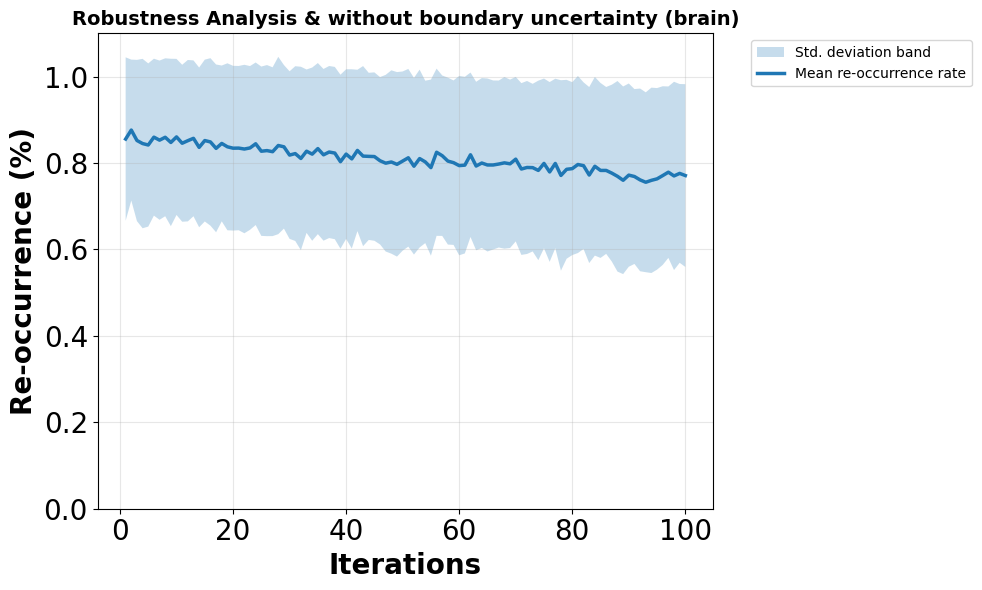

In [27]:
plot_robustness_seaborn(brain_results_nbd_noise, 
                        title="Robustness Analysis & without boundary uncertainty (brain)",
                       filename="brain_results_nbd_noise")

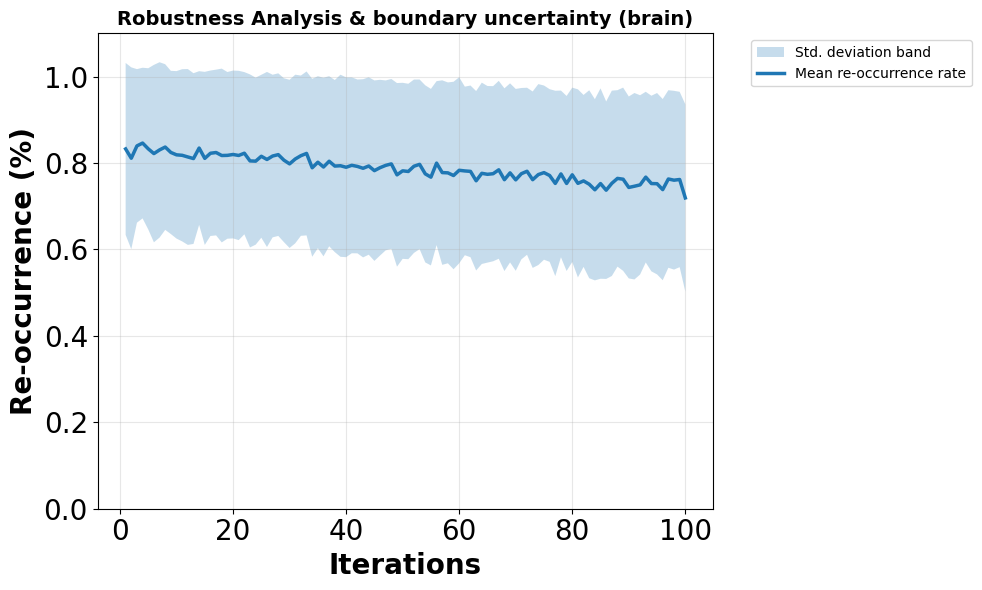

In [28]:
plot_robustness_seaborn(brain_results_bd_noise, 
                        title="Robustness Analysis & boundary uncertainty (brain)",
                       filename="brain_results_bd_noise")

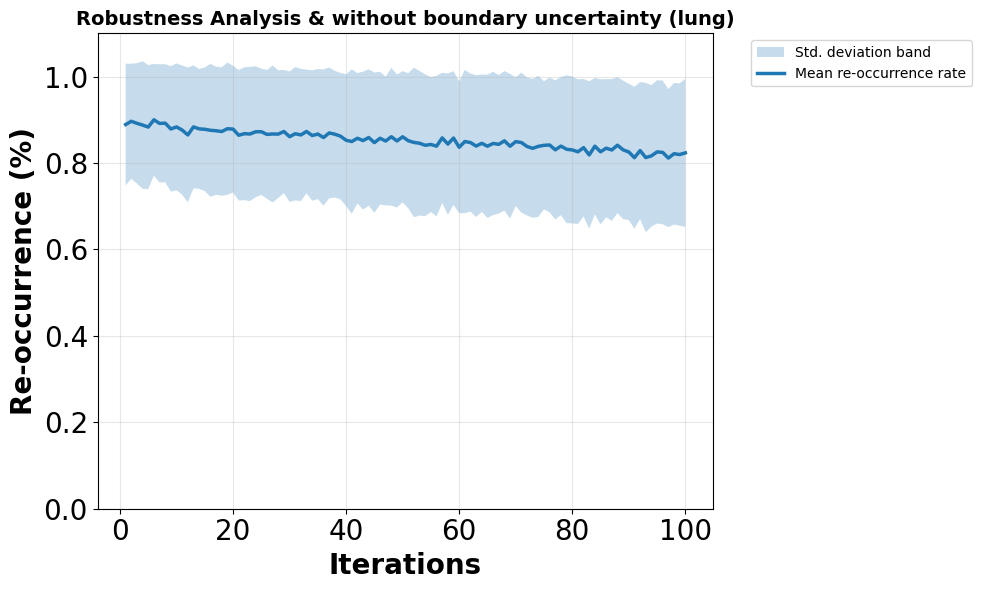

In [20]:
plot_robustness_seaborn(lung_results_nbd_noise, 
                        title="Robustness Analysis & without boundary uncertainty (lung)", 
                        filename="lung_results_nbd_noise")

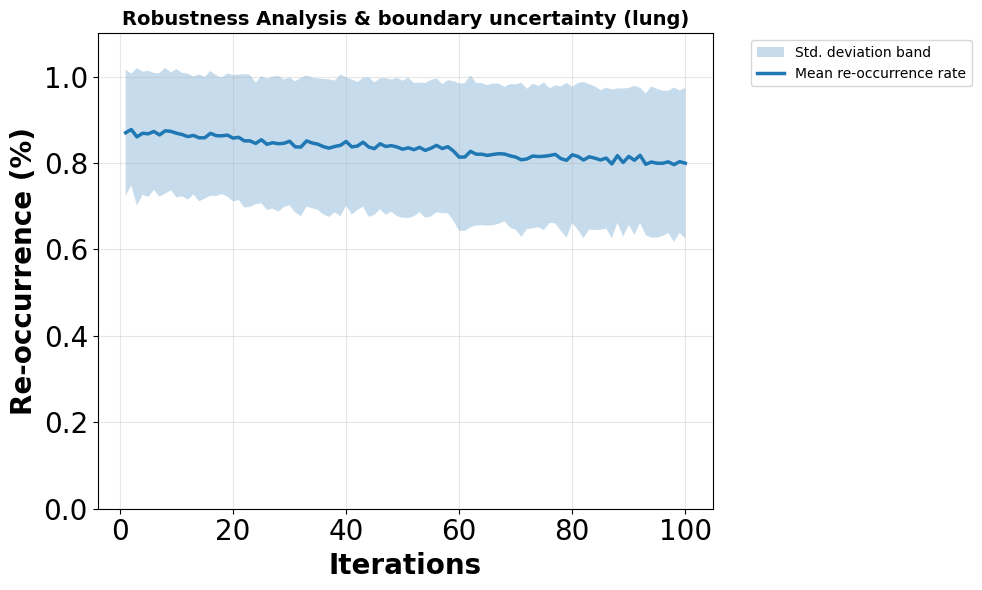

In [21]:
plot_robustness_seaborn(lung_results_bd_noise, 
                        title="Robustness Analysis & boundary uncertainty (lung)",
                        filename="lung_results_bd_noise")
